In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

LOADING DATA


In [5]:
try:
    file_path = "../data/processed/eda_ev_dataset.csv"
    
    df = pd.read_csv(file_path)
    
    print("Data Loaded Successfully")

except:
    print("File not found")

Data Loaded Successfully


EV ADOPTION ACCELERATION OVER TIME

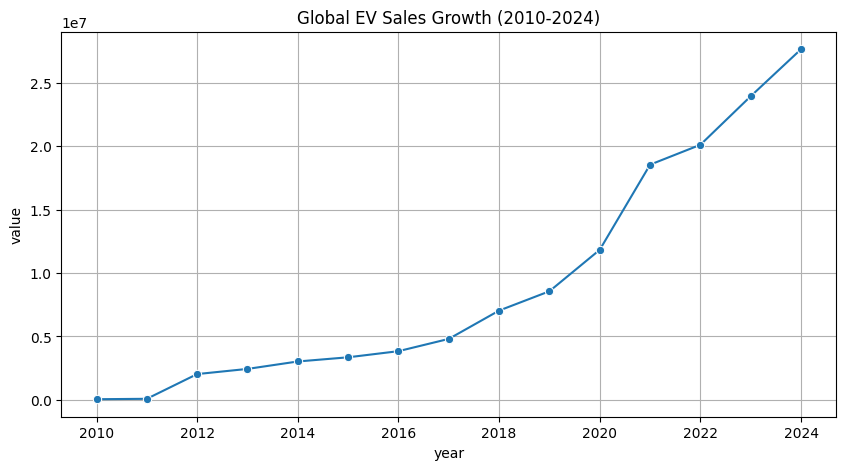

In [8]:
yearly_sales = (
    df.groupby("year")["value"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_sales, x="year", y="value", marker='o')
plt.title("Global EV Sales Growth (2010-2024)")
plt.grid('true')
plt.show()

WHICH COUNTRIES DOMINATE EV ADOPTION

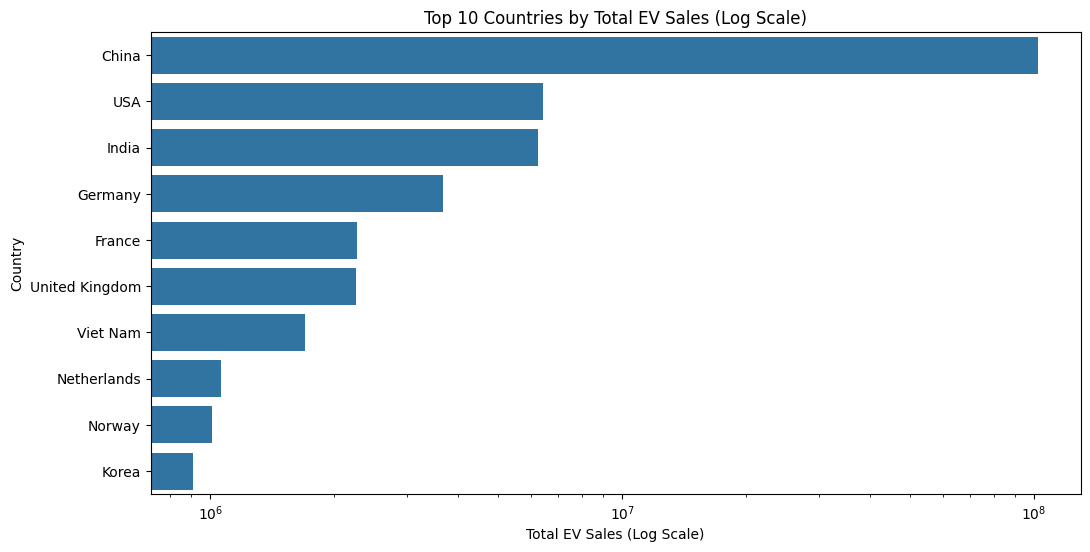

In [12]:
top_countries = (
    df.groupby("region_country")["value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.xscale("log")

plt.title("Top 10 Countries by Total EV Sales (Log Scale)")
plt.xlabel("Total EV Sales (Log Scale)")
plt.ylabel("Country")

plt.show()

EV SALES DISTRIBUTION

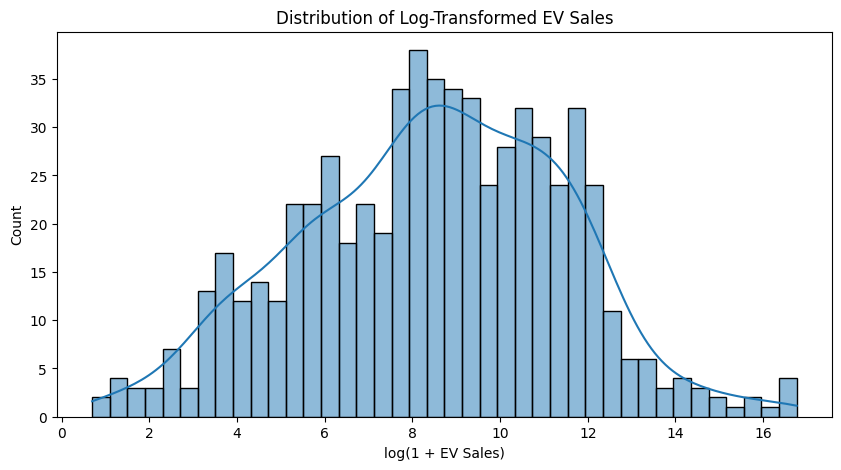

In [ ]:
import numpy as np

"""
Most countries have sales in the thousands.
China has sales in the millions.
Without a log transformation, eveything gets crushed near to zero.
A log transformation compresses large values and expands small values.

"""

df["log_sales"] = np.log1p(df["value"])

plt.figure(figsize=(10,5))

sns.histplot(
    df["log_sales"],
    bins=40,
    kde=True
)

plt.title("Distribution of Log-Transformed EV Sales")
plt.xlabel("log(1 + EV Sales)")
plt.show()